# Data Understanding — MAD Dataset
Exploratory analysis for the AI Agent Evaluation Framework thesis.
Dataset: `MAD_full_dataset.json` (1 242 traces, 7 frameworks, 14 MAST failure modes)

In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken

DATA_PATH = "MAD_full_dataset.json"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [9]:
with open(DATA_PATH) as f:
    raw = json.load(f)

df = pd.DataFrame([
    {
        "framework": d["mas_name"],
        "trace_id": d["trace_id"],
        "trajectory": d["trace"]["trajectory"],
        **{f"FM-{k}": v for k, v in d["mast_annotation"].items()},
    }
    for d in raw
])

FM_COLS = [c for c in df.columns if c.startswith("FM-")]
df["any_failure"] = df[FM_COLS].max(axis=1).astype(bool)

print(f"{len(df):,} traces | {df['framework'].nunique()} frameworks")
df.head(2)

1,242 traces | 7 frameworks


,framework,trace_id,trajectory,FM-1.1,FM-1.2,FM-1.3,FM-1.4,FM-1.5,FM-2.1,FM-2.2,FM-2.3,FM-2.4,FM-2.5,FM-2.6,FM-3.1,FM-3.2,FM-3.3,any_failure
0,ChatDev,0,[2025-31-03 19:09:41 INFO] **[Preprocessing]**...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False
1,ChatDev,1,[2025-31-03 19:30:18 INFO] **[Preprocessing]**...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False


## 1. Traces per framework & success / failure rate

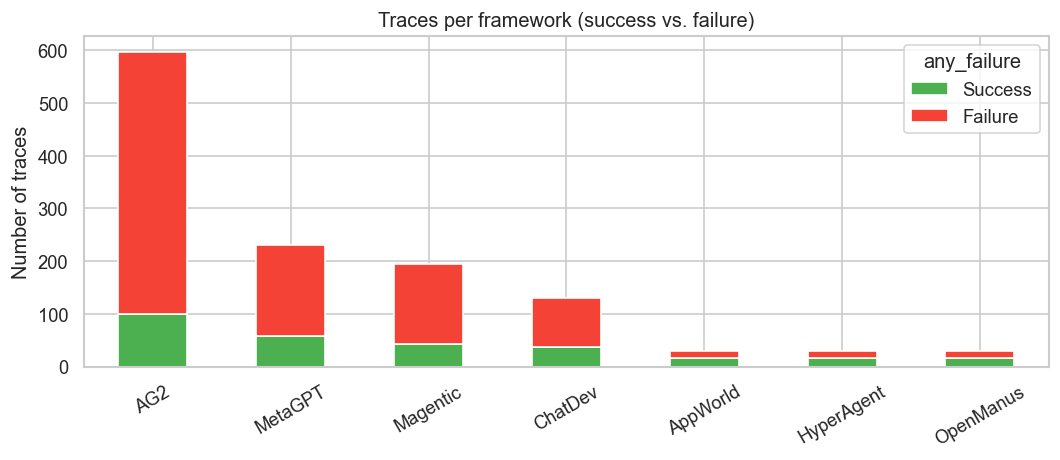

In [10]:
counts = (
    df.groupby(["framework", "any_failure"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "Success", True: "Failure"})
)
counts = counts.sort_values("Failure", ascending=False)

ax = counts.plot(kind="bar", stacked=True, figsize=(9, 4),
                 color=["#4CAF50", "#F44336"])
ax.set_title("Traces per framework (success vs. failure)")
ax.set_xlabel("")
ax.set_ylabel("Number of traces")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("fig_traces_per_framework.png")
plt.show()

## 2. Failure-mode prevalence

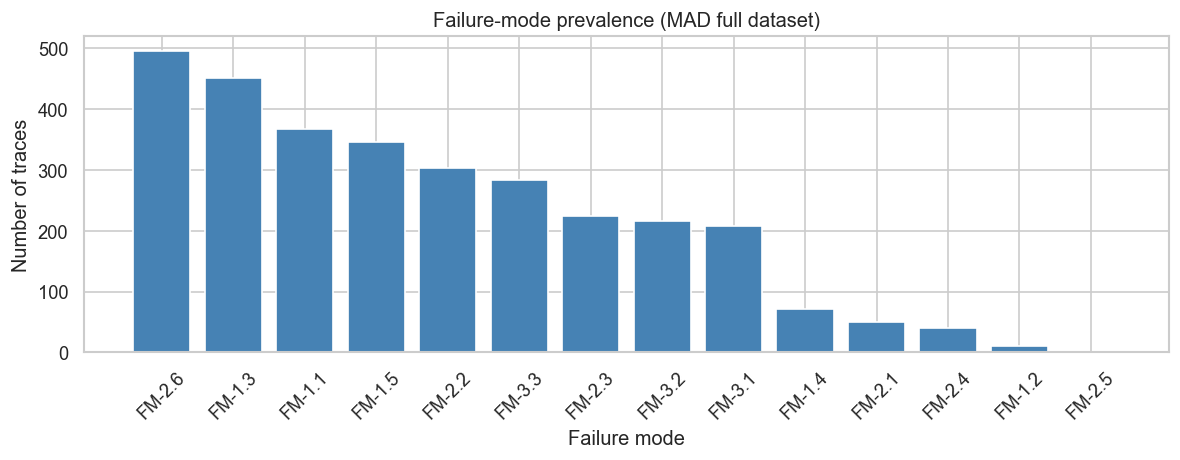

In [11]:
fm_counts = df[FM_COLS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(fm_counts.index, fm_counts.values, color="steelblue")
ax.set_title("Failure-mode prevalence (MAD full dataset)")
ax.set_xlabel("Failure mode")
ax.set_ylabel("Number of traces")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("fig_fm_prevalence.png")
plt.show()

## 3. Failure-mode co-occurrence (heatmap)

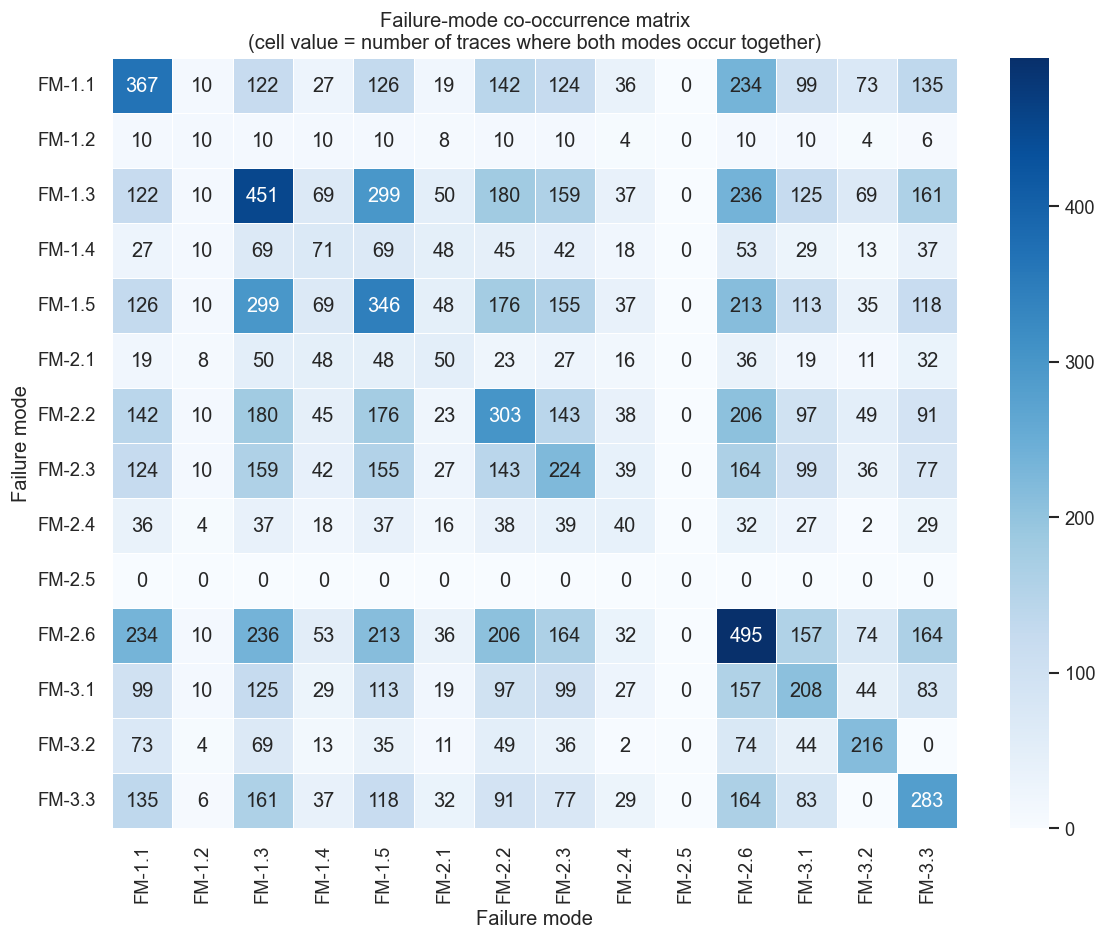

Diagonal (= how often each FM appears on its own):
FM-2.6    495
FM-1.3    451
FM-1.1    367
FM-1.5    346
FM-2.2    303
FM-3.3    283
FM-2.3    224
FM-3.2    216
FM-3.1    208
FM-1.4     71
FM-2.1     50
FM-2.4     40
FM-1.2     10
FM-2.5      0
dtype: int64


In [12]:
failed_traces = df.loc[df["any_failure"], FM_COLS]
cooccurrence = failed_traces.T.dot(failed_traces)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cooccurrence,
    annot=True,        # write the number inside each cell
    fmt="d",           # "d" = integer format (no decimals)
    cmap="Blues",      # darker blue = more co-occurrences
    linewidths=0.4,    # thin grid lines between cells
    ax=ax,
)

ax.set_title("Failure-mode co-occurrence matrix\n(cell value = number of traces where both modes occur together)")
ax.set_xlabel("Failure mode")
ax.set_ylabel("Failure mode")
plt.tight_layout()
plt.savefig("fig_fm_cooccurrence.png")
plt.show()

print("Diagonal (= how often each FM appears on its own):")
print(pd.Series(cooccurrence.values.diagonal(), index=cooccurrence.index).sort_values(ascending=False))

## 4. Trace Length Distributions (Tokens)

In [13]:
# Use a modern tokenizer (similar to GPT-4 family)
enc = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    return len(enc.encode(text))

print("Computing token counts...")
df["tokens"] = df["trajectory"].apply(count_tokens)
print("Done.")

df[["framework", "tokens"]].describe()

Computing token counts...
Done.


,tokens
count,1242.000000
mean,12076.438808
std,21242.802341
min,296.000000
25%,1115.250000
50%,1842.000000
75%,11769.750000
max,176380.000000


C:\Users\bramn\AppData\Local\Temp\ipykernel_21428\553950951.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_fw, labels=frameworks, showfliers=False)


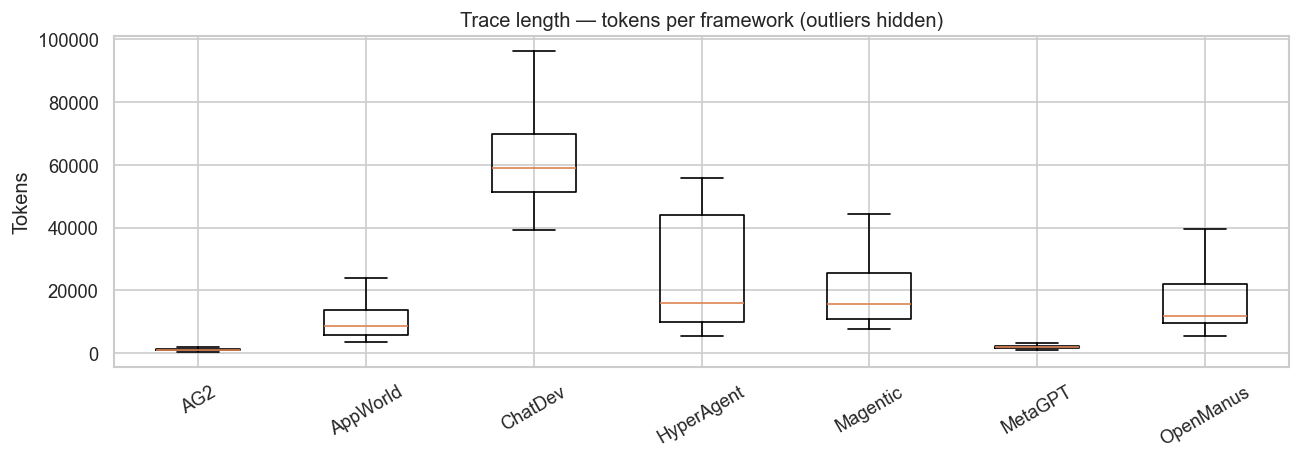

In [14]:
frameworks = sorted(df["framework"].unique())

fig, ax = plt.subplots(figsize=(11, 4))

data_by_fw = [df.loc[df["framework"] == fw, "tokens"].values for fw in frameworks]
ax.boxplot(data_by_fw, labels=frameworks, showfliers=False)
ax.set_title("Trace length — tokens per framework (outliers hidden)")
ax.set_ylabel("Tokens")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("fig_trace_length_distributions.png")
plt.show()